In [1]:

import pandas as pd
from sklearn.preprocessing import MinMaxScaler

#### 국토교통부 국토지리정보원_시계열행정구역
- https://www.data.go.kr/data/15122710/fileData.do?utm_source=chatgpt.com
- csv파일 다운로드
- 경로 : ``` /dataset/etc/국토교통부 국토지리정보원_시계열행정구역_20201201.csv ```


In [2]:
code_info_df = pd.read_csv('../dataset/etc/국토교통부 국토지리정보원_시계열행정구역_20201201.csv')
code_info_df = code_info_df.iloc[:,[1,2,4,5]]
code_info_df.columns = ['시도 코드', '시도 이름', '시군구 코드', '시군구 이름']
code_info_df

,시도 코드,시도 이름,시군구 코드,시군구 이름
0,11,서울특별시,11110,Jongno-gu
1,11,서울특별시,11140,Jung-gu
2,11,서울특별시,11170,Yongsan-gu
3,11,서울특별시,11200,Seongdong-gu
4,11,서울특별시,11215,Gwangjin-gu
...,...,...,...,...
224,44,충청남도,44270,Dangjin-si
225,44,충청남도,44760,Buyeo-gun
226,45,전라북도,45130,Gunsan-si
227,48,경상남도,48120,Changwon-si


In [3]:
df_api = pd.read_csv('./ref_dataset/방문자수_api.csv')
df_api

,Unnamed: 0,date,region,region_code,touDivNm,visitors
0,0,20230101,종로구,11110,현지인(a),97527.5
1,1,20230101,종로구,11110,외지인(b),280150.5
2,2,20230101,중구,11140,현지인(a),77854.0
3,3,20230101,중구,11140,외지인(b),255276.0
4,4,20230101,용산구,11170,현지인(a),135702.0
...,...,...,...,...,...,...
181995,181995,20231231,순창군,52770,외지인(b),13867.0
181996,181996,20231231,고창군,52790,현지인(a),29907.5
181997,181997,20231231,고창군,52790,외지인(b),31146.5
181998,181998,20231231,부안군,52800,현지인(a),29564.5


In [4]:

result_df = df_api.groupby(['region', 'region_code'])['visitors'].sum().reset_index()
result_df.reset_index(drop=True, inplace=True)

In [5]:
result_df

,region,region_code,visitors
0,가평군,41820,42095966.5
1,강남구,11680,406361721.5
2,강동구,11740,148226932.0
3,강릉시,51150,100094361.5
4,강북구,11305,84903997.5
...,...,...,...
245,홍천군,51720,31499576.5
246,화성시,41590,276594038.0
247,화순군,46790,27613414.5
248,화천군,51790,10884594.0


In [6]:

code_info_df_renamed = code_info_df.rename(columns={'시군구 코드': 'region_code'})
merged_df = pd.merge(result_df, code_info_df_renamed[['region_code', '시도 이름']], on='region_code', how='left')
merged_df['결합행정구역'] = merged_df['시도 이름'] + ' ' + merged_df['region']

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(merged_df[['visitors']])

merged_df['visitors_scaled'] = scaled_values


In [7]:
merged_df.to_csv('./ref_dataset/04_방문자수.csv')

In [8]:
merged_df

,region,region_code,visitors,시도 이름,결합행정구역,visitors_scaled
0,가평군,41820,42095966.5,경기도,경기도 가평군,0.094243
1,강남구,11680,406361721.5,서울특별시,서울특별시 강남구,1.000000
2,강동구,11740,148226932.0,서울특별시,서울특별시 강동구,0.358140
3,강릉시,51150,100094361.5,NaN,NaN,0.238457
4,강북구,11305,84903997.5,서울특별시,서울특별시 강북구,0.200686
...,...,...,...,...,...,...
245,홍천군,51720,31499576.5,NaN,NaN,0.067895
246,화성시,41590,276594038.0,경기도,경기도 화성시,0.677329
247,화순군,46790,27613414.5,전라남도,전라남도 화순군,0.058232
248,화천군,51790,10884594.0,NaN,NaN,0.016635


In [9]:
valid_col = ['결합행정구역', 'visitors']

In [11]:
merged_df[valid_col]

,결합행정구역,visitors
0,경기도 가평군,42095966.5
1,서울특별시 강남구,406361721.5
2,서울특별시 강동구,148226932.0
3,NaN,100094361.5
4,서울특별시 강북구,84903997.5
...,...,...
245,NaN,31499576.5
246,경기도 화성시,276594038.0
247,전라남도 화순군,27613414.5
248,NaN,10884594.0


In [12]:
merged_df = merged_df.dropna()


In [ ]:
merged_df[valid_col]

,region,region_code,visitors,시도 이름,결합행정구역,visitors_scaled
0,가평군,41820,42095966.5,경기도,경기도 가평군,0.094243
1,강남구,11680,406361721.5,서울특별시,서울특별시 강남구,1.000000
2,강동구,11740,148226932.0,서울특별시,서울특별시 강동구,0.358140
4,강북구,11305,84903997.5,서울특별시,서울특별시 강북구,0.200686
5,강서구,11500,172582301.5,서울특별시,서울특별시 강서구,0.418701
...,...,...,...,...,...,...
242,해남군,46820,21325234.0,전라남도,전라남도 해남군,0.042596
243,해운대구,26350,153969277.0,부산광역시,부산광역시 해운대구,0.372419
244,홍성군,44800,32829846.0,충청남도,충청남도 홍성군,0.071202
246,화성시,41590,276594038.0,경기도,경기도 화성시,0.677329


In [ ]:

# 상위 10개 지역 추출
top10_df = merged_df.sort_values(by='visitors', ascending=False).head(10)

# 막대그래프 그리기
fig = px.bar(
    top10_df,
    x='결합행정구역',
    y='visitors',
    title='방문자 수 상위 10개 지역',
    labels={'결합행정구역': '지역', 'visitors': '방문자 수'}
)
fig.update_layout(xaxis_tickangle=-45)  # x축 라벨 기울이기 (선택)
fig.show()

NameError: name 'pio' is not defined

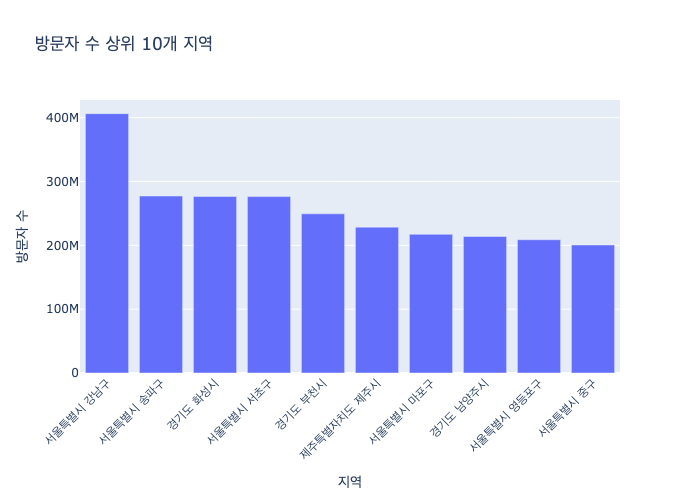

In [19]:
import plotly.io as pio
pio.show(fig, renderer="png")

In [20]:


# 하위 10개 지역 추출
bottom10_df = merged_df.sort_values(by='visitors', ascending=True).head(10)

# 막대그래프 그리기
fig = px.bar(
    bottom10_df,
    x='결합행정구역',
    y='visitors',
    title='방문자 수 하위 10개 지역',
    labels={'결합행정구역': '지역', 'visitors': '방문자 수'}
)
fig.update_layout(xaxis_tickangle=-45)  # x축 라벨 기울이기 (선택)
fig.show()


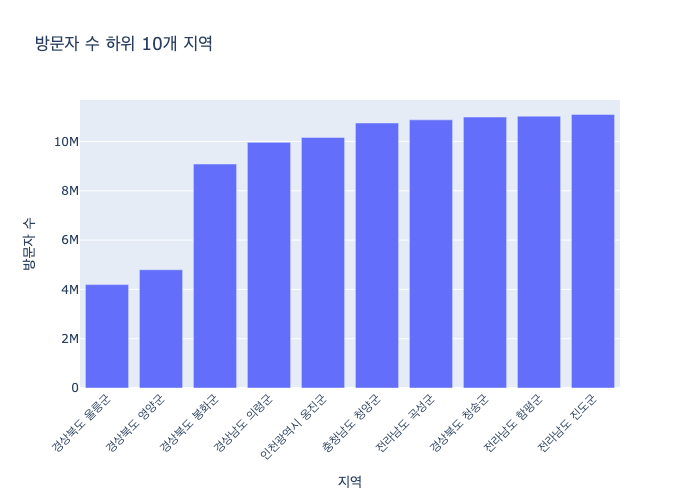

In [21]:
import plotly.io as pio
pio.show(fig, renderer="png")